# Лабораторная работа 1 — Загрузка табличных данных

**Цель работы:** изучить основные операции загрузки, просмотра и первичного анализа табличных данных с помощью библиотеки pandas.

## Теоретическое введение

**pandas** — основная библиотека Python для работы с табличными данными. Ключевые структуры данных:

- **DataFrame** — двумерная таблица (строки × столбцы), аналог таблицы в Excel или SQL. Каждый столбец — это `Series`.
- **Series** — одномерный массив с метками (индексом).

Основные операции с DataFrame:
- `pd.read_csv()` — загрузка из CSV-файла
- `.head(n)`, `.tail(n)` — первые/последние n строк
- `.sample(n)` — случайная выборка n строк
- `.iloc[:, i]` — выборка столбца по номеру
- `.describe()` — описательная статистика числовых столбцов
- `.groupby()` — группировка по значениям столбца
- Фильтрация: `df[df['column'] > value]` — выборка строк по условию

Для визуализации используется **matplotlib** — библиотека построения графиков, и **seaborn** — надстройка для статистических визуализаций.

## 1. Импорт библиотек и загрузка данных

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

data = pd.read_csv('../../datasets/gtzan/features_30_sec.csv')
print(f'Датасет загружен: {data.shape[0]} строк, {data.shape[1]} столбцов')
print(f'\nСтолбцы: {list(data.columns)}')

Датасет загружен: 1000 строк, 60 столбцов

Столбцы: ['filename', 'length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean', 'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var', 'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean', 'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var', 'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var', 'tempo', 'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean', 'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var', 'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean', 'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var', 'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean', 'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var', 'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean', 'mfcc18_var', 'mfcc19_mean', 'mfcc19_var', 'mfcc20_mean', 'mfcc20_var', 'label']


## 2. Обзор данных

Посмотрим на типы данных, наличие пропусков и общую структуру датасета.

In [7]:
data.info()
print(f'\nПропуски: {data.isnull().sum().sum()}')
data.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 60 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   filename                 1000 non-null   str    
 1   length                   1000 non-null   int64  
 2   chroma_stft_mean         1000 non-null   float64
 3   chroma_stft_var          1000 non-null   float64
 4   rms_mean                 1000 non-null   float64
 5   rms_var                  1000 non-null   float64
 6   spectral_centroid_mean   1000 non-null   float64
 7   spectral_centroid_var    1000 non-null   float64
 8   spectral_bandwidth_mean  1000 non-null   float64
 9   spectral_bandwidth_var   1000 non-null   float64
 10  rolloff_mean             1000 non-null   float64
 11  rolloff_var              1000 non-null   float64
 12  zero_crossing_rate_mean  1000 non-null   float64
 13  zero_crossing_rate_var   1000 non-null   float64
 14  harmony_mean             1000 non-nu

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues


## 3. Выборка столбцов

Выведем первый и третий столбцы по отдельности, а затем вместе. Используем `.iloc` для доступа по номеру.

In [3]:
# Первый столбец (filename)
print('=== Первый столбец ===')
print(data.iloc[:, 0].head(10))

print('\n=== Третий столбец ===')
print(data.iloc[:, 2].head(10))

print('\n=== Первый и третий вместе ===')
data.iloc[:, [0, 2]].head(10)

=== Первый столбец ===
0    blues.00000.wav
1    blues.00001.wav
2    blues.00002.wav
3    blues.00003.wav
4    blues.00004.wav
5    blues.00005.wav
6    blues.00006.wav
7    blues.00007.wav
8    blues.00008.wav
9    blues.00009.wav
Name: filename, dtype: str

=== Третий столбец ===
0    0.350088
1    0.340914
2    0.363637
3    0.404785
4    0.308526
5    0.302456
6    0.291328
7    0.307955
8    0.408879
9    0.273950
Name: chroma_stft_mean, dtype: float64

=== Первый и третий вместе ===


,filename,chroma_stft_mean
0,blues.00000.wav,0.350088
1,blues.00001.wav,0.340914
2,blues.00002.wav,0.363637
3,blues.00003.wav,0.404785
4,blues.00004.wav,0.308526
5,blues.00005.wav,0.302456
6,blues.00006.wav,0.291328
7,blues.00007.wav,0.307955
8,blues.00008.wav,0.408879
9,blues.00009.wav,0.273950


## 4. Выборка строк

Выведем первые 10 строк (`head`) и 23 случайных строки (`sample`).

In [4]:
print('=== Первые 10 строк ===')
data.head(10)

=== Первые 10 строк ===


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,1.297741e+05,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,3.758501e+05,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,1.564676e+05,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,1.843559e+05,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,3.433999e+05,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues
5,blues.00005.wav,661794,0.302456,0.087532,0.103494,0.003981,1831.993940,1.030482e+06,1729.653287,201910.508633,...,72.549225,-1.838263,68.702026,-2.783800,42.447453,-3.047909,39.808784,-8.109991,46.311005,blues
6,blues.00006.wav,661794,0.291328,0.093981,0.141874,0.008803,1459.366472,4.378594e+05,1389.009131,185023.239545,...,83.248245,-10.913176,56.902153,-6.971336,38.231800,-3.436505,48.235741,-6.483466,70.170364,blues
7,blues.00007.wav,661794,0.307955,0.092903,0.131822,0.005531,1451.667066,4.495682e+05,1577.270941,168211.938804,...,70.438438,-10.568935,52.090893,-10.784515,60.461330,-4.690678,65.547516,-8.630722,56.401436,blues
8,blues.00008.wav,661794,0.408879,0.086512,0.142416,0.001507,1719.368948,1.632828e+05,2031.740381,105542.718193,...,50.563751,-7.041824,28.894934,2.695248,36.889568,3.412305,33.698597,-2.715692,36.418430,blues
9,blues.00009.wav,661794,0.273950,0.092316,0.081314,0.004347,1817.150863,2.982361e+05,1973.773306,114070.112591,...,59.314602,-1.916804,58.418438,-2.292661,83.205231,2.881967,77.082222,-4.235203,91.468811,blues


In [5]:
print('=== 23 случайных строки ===')
data.sample(23, random_state=42)

=== 23 случайных строки ===


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
521,jazz.00021.wav,661794,0.432707,0.087017,0.047977,0.000411,2915.017702,4.659886e+05,2420.421212,55397.978934,...,52.428093,-6.002379,44.046604,2.347543,57.231190,-3.352306,68.406425,2.508936,58.562813,jazz
737,pop.00037.wav,661504,0.451825,0.085256,0.240985,0.008035,3238.215472,6.352632e+05,2954.126414,167148.237400,...,47.259617,-2.177770,38.882034,-1.600560,51.832035,-0.616253,57.315872,-4.048588,53.083454,pop
740,pop.00040.wav,661504,0.292264,0.085571,0.199328,0.005632,1962.036801,2.613075e+05,2325.013206,179382.875864,...,72.924728,-0.548955,78.905830,-0.568484,87.446632,0.643941,66.528664,-1.999727,107.257652,pop
660,metal.00060.wav,661794,0.540349,0.059563,0.125761,0.000635,2315.317248,1.152508e+05,2066.651952,37095.019096,...,21.919737,-6.810860,24.919960,4.214549,15.420555,-3.401198,20.339085,1.762156,17.411707,metal
411,hiphop.00011.wav,661794,0.444012,0.085203,0.203773,0.006599,2095.420824,4.303135e+05,2241.060906,110796.012282,...,76.894180,-2.812528,101.614967,6.798242,107.964317,-5.803802,103.876694,-3.767237,92.247749,hiphop
678,metal.00078.wav,661504,0.533737,0.069358,0.269671,0.001759,2814.978063,3.640428e+05,2548.011410,103382.047807,...,32.903320,-6.442894,26.797279,2.228225,27.616133,-3.008769,28.833046,1.980235,21.495506,metal
626,metal.00026.wav,661504,0.484610,0.072828,0.138212,0.000503,2870.818647,6.264696e+04,2126.733591,22612.198114,...,31.784739,-8.119671,52.805080,-1.439807,30.383093,-0.951388,48.310558,0.816148,42.142365,metal
513,jazz.00013.wav,661794,0.314325,0.088912,0.055482,0.000310,1789.982726,8.787790e+04,2312.885935,48958.434409,...,84.707123,-2.782915,80.865334,1.273962,59.723904,-0.347826,60.870331,0.359693,73.107010,jazz
859,reggae.00059.wav,661504,0.375856,0.085602,0.126457,0.001965,2671.459793,8.231788e+05,2716.559623,203466.668347,...,61.214920,-4.059788,62.772442,-3.176068,43.734417,-5.431156,49.247871,-2.143111,62.694115,reggae
136,classical.00036.wav,661794,0.239277,0.089015,0.015999,0.000190,1282.285639,3.021590e+05,1503.503330,133866.302666,...,89.485115,7.015224,136.465408,5.587258,143.682663,-3.467517,170.032700,-5.173669,84.984337,classical


## 5. Фильтрация по условию

Отфильтруем треки с высоким значением `chroma_stft_mean` (выше медианы).

In [8]:
median_chroma = data['chroma_stft_mean'].median()
filtered = data[data['chroma_stft_mean'] > median_chroma]
print(f'Медиана chroma_stft_mean: {median_chroma:.4f}')
print(f'Строк после фильтрации: {len(filtered)} из {len(data)}')
filtered[['filename', 'chroma_stft_mean', 'label']].head(10)

Медиана chroma_stft_mean: 0.3831
Строк после фильтрации: 500 из 1000


,filename,chroma_stft_mean,label
3,blues.00003.wav,0.404785,blues
8,blues.00008.wav,0.408879,blues
40,blues.00040.wav,0.397996,blues
41,blues.00041.wav,0.386868,blues
43,blues.00043.wav,0.398921,blues
44,blues.00044.wav,0.390175,blues
45,blues.00045.wav,0.429437,blues
46,blues.00046.wav,0.387967,blues
50,blues.00050.wav,0.400936,blues
51,blues.00051.wav,0.393688,blues


## 6. Описательная статистика

Метод `describe()` выводит основные статистические характеристики числовых столбцов: среднее, стд. отклонение, квартили.

In [7]:
data.describe().round(3)

,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,...,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,662030.846,0.379,0.086,0.131,0.003,2201.781,469691.575,2242.541,137079.155,4571.549,...,1.148,60.731,-3.966,62.634,0.508,63.713,-2.329,66.232,-1.095,70.126
std,1784.074,0.082,0.008,0.066,0.004,715.961,400899.517,526.316,96455.666,1574.792,...,4.579,33.782,4.550,33.479,3.869,34.402,3.756,37.175,3.837,45.229
min,660000.000,0.172,0.045,0.005,0.000,570.040,7911.251,898.066,10787.185,749.141,...,-15.694,9.169,-17.235,13.932,-11.964,15.421,-18.502,13.488,-19.930,7.957
25%,661504.000,0.320,0.082,0.087,0.001,1627.697,184350.530,1907.241,67376.554,3380.070,...,-1.863,40.376,-7.207,40.831,-2.007,41.884,-4.663,41.710,-3.369,42.373
50%,661794.000,0.383,0.087,0.122,0.002,2209.263,338486.153,2221.393,111977.548,4658.524,...,1.213,52.325,-4.066,54.718,0.670,54.805,-2.394,57.423,-1.166,59.186
75%,661794.000,0.436,0.091,0.176,0.004,2691.295,612147.935,2578.470,182371.577,5533.810,...,4.360,71.692,-0.839,75.041,3.119,75.386,0.151,78.626,1.313,85.375
max,675808.000,0.664,0.108,0.398,0.028,4435.244,3036843.062,3509.646,694784.812,8677.673,...,13.457,392.932,11.483,406.059,15.388,332.905,14.695,393.162,15.370,506.065


## 7. Группировка по жанру

Сгруппируем данные по столбцу `label` (жанр) и посмотрим статистику для каждой группы.

In [20]:
group = data.groupby('label')
print('=== Количество треков по жанрам ===')
print(group.size())
print('\n=== Среднее tempo по жанрам ===')
group['tempo'].mean().sort_values(ascending=False)

=== Количество треков по жанрам ===
label
blues        100
classical    100
country      100
disco        100
hiphop       100
jazz         100
metal        100
pop          100
reggae       100
rock         100
dtype: int64

=== Среднее tempo по жанрам ===


label
reggae       129.279738
classical    127.920952
metal        124.873912
blues        120.742207
disco        120.341798
rock         120.262441
jazz         115.068143
hiphop       112.945646
pop          112.759957
country      110.858840
Name: tempo, dtype: float64

In [9]:
# Группировка по другим столбцам: статистика spectral_centroid_mean по жанрам
group[['spectral_centroid_mean', 'rms_mean', 'tempo']].describe().round(2)

spectral_centroid_mean                                              \
                           count     mean     std      min      25%      50%   
label                                                                          
blues                      100.0  1727.58  515.53   570.04  1316.61  1630.68   
classical                  100.0  1353.88  348.16   690.20  1171.10  1344.96   
country                    100.0  1896.21  575.91   857.64  1507.40  1767.22   
disco                      100.0  2619.85  478.81  1710.87  2289.19  2545.41   
hiphop                     100.0  2524.52  479.29  1470.31  2243.60  2500.51   
jazz                       100.0  1792.36  680.64   749.35  1315.37  1692.85   
metal                      100.0  2602.18  368.57  1443.33  2366.87  2683.28   
pop                        100.0  3073.55  582.12  1826.48  2740.56  3143.66   
reggae                     100.0  2185.02  626.60  1052.21  1754.02  2069.97   
rock                       100.0  2242.66  483.80  1181.23  1877.74  2278.67   

                            rms_mean        ...              tempo          \
               75%      max    count  mean  ...   75%   max  count    mean   
label                                       ...                              
blues      2162.41  2840.06    100.0  0.14  ...  0.17  0.27  100.0  120.74   
classical  1518.90  2423.30    100.0  0.04  ...  0.04  0.19  100.0  127.92   
country    2257.97  3760.29    100.0  0.13  ...  0.15  0.27  100.0  110.86   
disco      2968.04  3715.27    100.0  0.14  ...  0.17  0.29  100.0  120.34   
hiphop     2783.17  3785.40    100.0  0.18  ...  0.23  0.30  100.0  112.95   
jazz       2038.27  4135.66    100.0  0.09  ...  0.11  0.23  100.0  115.07   
metal      2820.46  3403.07    100.0  0.15  ...  0.21  0.31  100.0  124.87   
pop        3503.48  4225.53    100.0  0.20  ...  0.23  0.40  100.0  112.76   
reggae     2469.77  4435.24    100.0  0.12  ...  0.14  0.35  100.0  129.28   
rock       2561.46  3488.55    100.0  0.13  ...  0.15  0.26  100.0  120.26   

                                                         
             std    min     25%     50%     75%     max  
label                                                    
blues      31.79  58.73   98.46  123.05  143.55  198.77  
classical  33.70  68.00   99.38  123.05  152.00  234.91  
country    29.64  60.09   86.13  112.35  130.90  184.57  
disco      14.22  86.13  112.35  123.05  129.20  184.57  
hiphop     27.73  71.78   95.70  103.36  117.45  198.77  
jazz       30.65  54.98   95.70  107.67  129.20  215.33  
metal      25.12  61.52  107.67  123.05  143.55  184.57  
pop        24.64  58.73   99.38  107.67  123.05  215.33  
reggae     29.43  76.00   99.38  129.20  152.00  198.77  
rock       25.24  73.83  103.36  117.45  129.20  198.77  

[10 rows x 24 columns]

## 8. Визуализации

Визуализируем основные характеристики датасета.

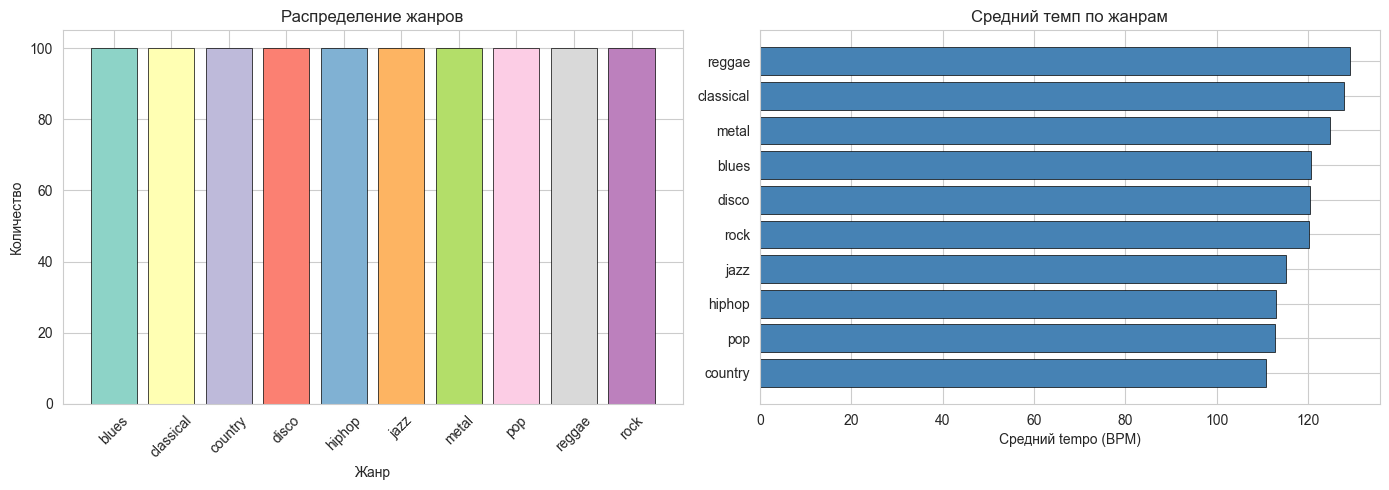

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение жанров
genre_counts = data['label'].value_counts()
axes[0].bar(genre_counts.index, genre_counts.values, color=sns.color_palette('Set3', 10),
            edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Жанр')
axes[0].set_ylabel('Количество')
axes[0].set_title('Распределение жанров')
axes[0].tick_params(axis='x', rotation=45)

# Средний tempo по жанрам
tempo_by_genre = group['tempo'].mean().sort_values()
axes[1].barh(tempo_by_genre.index, tempo_by_genre.values, color='steelblue',
             edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('Средний tempo (BPM)')
axes[1].set_title('Средний темп по жанрам')

plt.tight_layout()
plt.show()

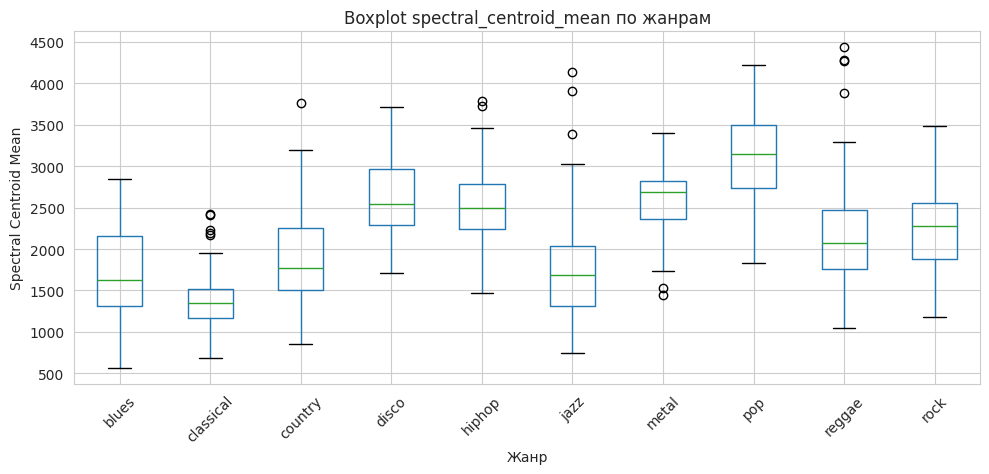

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
data.boxplot(column='spectral_centroid_mean', by='label', ax=ax, rot=45)
ax.set_xlabel('Жанр')
ax.set_ylabel('Spectral Centroid Mean')
ax.set_title('Boxplot spectral_centroid_mean по жанрам')
plt.suptitle('')
plt.tight_layout()
plt.show()

## Выводы

1. Датасет GTZAN содержит 1000 треков (10 жанров × 100 треков) с 60 столбцами (57 числовых аудио-признаков + filename, length, label).

2. Данные полностью заполнены — пропусков нет.

3. Фильтрация по `chroma_stft_mean > медиана` отсекает ровно половину данных, что подтверждает симметричность распределения.

4. Группировка по жанрам показала, что датасет сбалансирован (по 100 треков на жанр), а средний tempo различается: самый быстрый — disco/metal, самый медленный — blues/classical.

5. Boxplot `spectral_centroid_mean` наглядно показывает, что metal и pop имеют самые высокие спектральные центроиды, а classical — самые низкие.